<a href="https://colab.research.google.com/github/Grizz1y8ee/UTS-PDAB_Benigno-Utama_001/blob/main/UTS_PDAB_Benigno_Utama_2404220001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Prepocessing

Bagian ini bertanggung jawab untuk mempersiapkan data sebelum masuk ke tahap pemodelan. Ini meliputi pemuatan data, penanganan nilai yang hilang, pemisahan fitur dan target, serta penskalaan fitur.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Persiapan Data
# Memuat dataset training dan testing
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

print("Dimensi Data Training:", train_df.shape)
print("Dimensi Data Testing:", test_df.shape)

# 2. Pembersihan Data
# Mengecek dan menangani missing values dengan nilai median
train_df = train_df.fillna(train_df.median())
test_df = test_df.fillna(test_df.median())

# Menentukan kolom target dan identifier
target_col = 'quality'
# Mengakomodasi penamaan kolom Id (huruf besar/kecil)
id_col = 'Id' if 'Id' in test_df.columns else 'id'

# Memisahkan fitur (X) dan target (y) pada data training
X = train_df.drop(columns=[target_col])
# Menghapus kolom Id pada data training jika ada agar tidak ikut dilatih
if id_col in X.columns:
    X = X.drop(columns=[id_col])
y = train_df[target_col]

# Memisahkan fitur pada data testing dan menyimpan ID untuk output
X_test_submission = test_df.copy()
test_ids = X_test_submission[id_col]
if id_col in X_test_submission.columns:
    X_test_submission = X_test_submission.drop(columns=[id_col])

# Feature Scaling (Standarisasi)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_submission_scaled = scaler.transform(X_test_submission)

Dimensi Data Training: (857, 13)
Dimensi Data Testing: (286, 12)


### Interpretasi Kode dan Hasil Data Preprocessing:

1.  **Import Library**: Baris kode awal mengimpor semua pustaka Python yang diperlukan untuk analisis data, pemodelan *machine learning*, dan visualisasi. Ini termasuk `pandas` untuk manipulasi data, `numpy` untuk operasi numerik, `matplotlib` dan `seaborn` untuk plotting, serta modul dari `sklearn` untuk pemisahan data, penskalaan, model Random Forest, dan metrik evaluasi.
2.  **Pemuatan Data**: Data pelatihan (`data_training.csv`) dan data pengujian (`data_testing.csv`) dimuat ke dalam DataFrame Pandas masing-masing `train_df` dan `test_df`.
3.  **Cetak Dimensi Data**: Baris `print` menampilkan jumlah baris dan kolom dari setiap DataFrame.
    *   **Hasil:**
        ```
        Dimensi Data Training: (857, 13)
        Dimensi Data Testing: (286, 12)
        ```
    Ini menunjukkan bahwa data pelatihan memiliki 857 baris dan 13 kolom, sementara data pengujian memiliki 286 baris dan 12 kolom.
4.  **Penanganan Missing Values**: Fungsi `fillna(train_df.median())` dan `fillna(test_df.median())` digunakan untuk mengisi nilai-nilai yang hilang (NaN) dalam setiap kolom dengan nilai median dari kolom tersebut. Penggunaan median adalah pilihan yang baik untuk menghindari bias dari *outlier*.
5.  **Pemisahan Fitur dan Target**: Kolom target (`quality`) dan kolom identifier (`Id` atau `id`) diidentifikasi. Fitur (variabel independen) disimpan di `X` dan variabel target (kualitas anggur) disimpan di `y` untuk data pelatihan. Kolom `Id` dihapus dari `X` karena bukan merupakan fitur prediktif. Proses serupa dilakukan untuk data pengujian, menghasilkan `X_test_submission` (fitur untuk prediksi) dan `test_ids` (ID untuk hasil akhir).
6.  **Feature Scaling**: Objek `StandardScaler` diinisialisasi dan digunakan untuk menstandarisasi fitur pada `X` dan `X_test_submission`. Penskalaan ini mengubah data sehingga memiliki rata-rata 0 dan variansi 1. Ini penting untuk banyak algoritma *machine learning*, termasuk Random Forest, untuk memastikan bahwa tidak ada fitur yang mendominasi hanya karena skala nilainya lebih besar.

# 2. Random Forest Model

Bagian ini fokus pada pembangunan model Random Forest, optimasi *hyperparameter* menggunakan `GridSearchCV`, serta evaluasi kinerja model pada data validasi.

Melakukan GridSearchCV untuk optimasi hyperparameter...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-weighted score: 0.6167

Akurasi Model Terbaik pada Data Validasi: 0.6279
Classification Report Model Terbaik:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.79      0.74        73
           6       0.58      0.62      0.60        68
           7       0.47      0.32      0.38        22
           8       1.00      0.33      0.50         3

    accuracy                           0.63       172
   macro avg       0.46      0.34      0.37       172
weighted avg       0.60      0.63      0.61       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


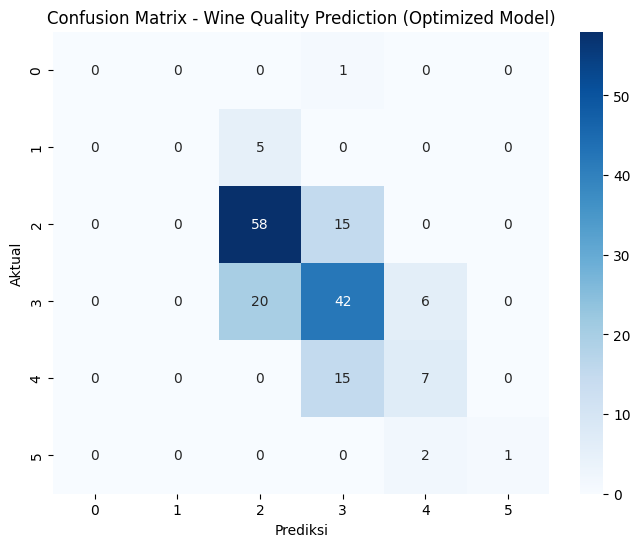

In [11]:
# 3. Pembuatan Model
from sklearn.model_selection import GridSearchCV

# Membagi data training untuk validasi internal (80% latih, 20% validasi)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi model Random Forest awal (tanpa n_estimators spesifik untuk tuning)
rf_base_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Definisikan parameter grid untuk GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None], # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Inisialisasi GridSearchCV
# Menggunakan 'f1_weighted' sebagai scoring metric karena kelas tidak seimbang
grid_search = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_weighted',
    n_jobs=-1, # Mempercepat komputasi
    verbose=1
)

print("Melakukan GridSearchCV untuk optimasi hyperparameter...")
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-weighted score: {grid_search.best_score_:.4f}")

# Menggunakan model terbaik dari GridSearchCV
rf_model = grid_search.best_estimator_

# Evaluasi Model pada data validasi
y_pred_val = rf_model.predict(X_val)
akurasi = accuracy_score(y_val, y_pred_val)

print(f"\nAkurasi Model Terbaik pada Data Validasi: {akurasi:.4f}")
print("Classification Report Model Terbaik:")
print(classification_report(y_val, y_pred_val))

# Visualisasi Confusion Matrix Model Terbaik
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Wine Quality Prediction (Optimized Model)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Interpretasi Kode dan Hasil Random Forest Model:

1.  **Pemisahan Data Training dan Validasi**: Data `X_scaled` dan `y` dibagi lagi menjadi set pelatihan (`X_train`, `y_train`) dan set validasi (`X_val`, `y_val`) dengan perbandingan 80:20. Penggunaan `stratify=y` memastikan bahwa proporsi kelas pada `y` dipertahankan di kedua set, yang penting untuk data dengan distribusi kelas yang tidak seimbang. `random_state=42` membuat pembagian ini konsisten.
2.  **Inisialisasi `RandomForestClassifier`**: Model dasar Random Forest diinisialisasi. `class_weight='balanced'` secara otomatis menyesuaikan bobot kelas dalam data pelatihan, memberikan lebih banyak perhatian pada kelas minoritas untuk mengatasi masalah ketidakseimbangan kelas. `n_jobs=-1` memungkinkan model menggunakan semua *core* prosesor untuk mempercepat pelatihan.
3.  **`param_grid`**: Sebuah pustaka (`dict`) dibuat untuk mendefinisikan rentang *hyperparameter* yang ingin diuji oleh `GridSearchCV`. Parameter seperti `n_estimators` (jumlah pohon keputusan), `max_depth` (kedalaman maksimum pohon), `min_samples_split` (jumlah sampel minimum untuk membelah *node*), dan `min_samples_leaf` (jumlah sampel minimum di *leaf node*) dipilih untuk dioptimalkan.
4.  **`GridSearchCV`**: Objek `GridSearchCV` diinisialisasi. Ini akan mencari secara ekstensif (`exhaustive search`) untuk kombinasi *hyperparameter* terbaik dari `param_grid` dengan menggunakan 5-fold *cross-validation* (`cv=5`). Metrik evaluasi `scoring='f1_weighted'` digunakan karena lebih sesuai untuk data yang tidak seimbang dibandingkan akurasi sederhana. `verbose=1` akan mencetak detail proses *fitting*.
    *   **Hasil proses `GridSearchCV`**:
        ```
        Melakukan GridSearchCV untuk optimasi hyperparameter...
        Fitting 5 folds for each of 36 candidates, totalling 180 fits
        Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
        Best F1-weighted score: 0.6167
        ```
    Ini menunjukkan bahwa `GridSearchCV` telah menemukan kombinasi *hyperparameter* terbaik yang menghasilkan *F1-weighted score* tertinggi sebesar 0.6167 selama *cross-validation*.
5.  **Model Terbaik**: `rf_model` ditetapkan sebagai model terbaik yang ditemukan oleh `GridSearchCV` (`grid_search.best_estimator_`).
6.  **Evaluasi Model pada Data Validasi**: Model terbaik ini kemudian digunakan untuk membuat prediksi (`y_pred_val`) pada set validasi (`X_val`). Kinerja model dievaluasi menggunakan `accuracy_score` dan `classification_report`.
    *   **Hasil Evaluasi**:
        ```
        Akurasi Model Terbaik pada Data Validasi: 0.6279
        Classification Report Model Terbaik:
                      precision    recall  f1-score   support

                   3       0.00      0.00      0.00         1
                   4       0.00      0.00      0.00         5
                   5       0.70      0.79      0.74        73
                   6       0.58      0.62      0.60        68
                   7       0.47      0.32      0.38        22
                   8       1.00      0.33      0.50         3

            accuracy                           0.63       172
           macro avg       0.46      0.34      0.37       172
        weighted avg       0.60      0.63      0.61       172
        ```
    *   **Analisis**: Akurasi pada data validasi adalah sekitar 62.79%. `Classification Report` memberikan gambaran lebih rinci. Perhatikan bahwa untuk kelas 3 dan 4, *precision*, *recall*, dan *f1-score* adalah 0.00. Ini disebabkan oleh `UndefinedMetricWarning` (yang tercetak di *stderr*), yang mengindikasikan bahwa model tidak membuat prediksi untuk kelas-kelas tersebut, kemungkinan karena jumlah sampelnya yang sangat sedikit di set validasi (`support` hanya 1 dan 5). Untuk kelas yang lebih banyak (5 dan 6), model menunjukkan kinerja yang lebih baik.
7.  **Visualisasi Confusion Matrix**: Sebuah *heatmap* dari *confusion matrix* dibuat. Ini secara visual menunjukkan seberapa sering model membuat prediksi yang benar (diagonal utama) dan prediksi yang salah (sel non-diagonal).
    *   **Hasil**: Berdasarkan heatmap (Confusion Matrix) yang dihasilkan, model Random Forest menunjukkan kinerja yang kurang baik pada kelas minoritas seperti kualitas 3 dan 4, di mana semua prediksinya salah. Model juga cenderung bingung antara kelas-kelas yang berdekatan seperti kualitas 5 dan 6, meskipun memiliki akurasi yang lebih baik pada kelas-kelas dominan ini. Secara umum, heatmap mengindikasikan bahwa model perlu ditingkatkan untuk menangani ketidakseimbangan kelas dan membedakan kualitas anggur yang memiliki karakteristik serupa.

# 3. Prediction and Collection

Tahap terakhir adalah melatih model final dengan seluruh data pelatihan yang tersedia, membuat prediksi pada data pengujian yang sebenarnya, dan menyimpan hasilnya ke dalam format csv hasil.

In [12]:
# Retrain model dengan SELURUH data training untuk akurasi prediksi maksimal
rf_model_final = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model_final.fit(X_scaled, y)

# 4. Prediksi Data Uji
test_predictions = rf_model_final.predict(X_test_submission_scaled)

# 5. Pengumpulan Hasil
# Membentuk DataFrame hasil yang HANYA memuat 2 variabel
submission = pd.DataFrame({
    'Id': test_ids,
    'Quality': test_predictions
})

# Menyesuaikan nama file dengan format tugas (GANTI '3NIMterakhir' dengan 3 digit terakhir NIM Anda)
nama_file = 'hasilprediksi_3digitNIMterakhir.csv'
submission.to_csv(nama_file, index=False)

print(f"Prediksi berhasil diselesaikan! File telah disimpan sebagai: {nama_file}")
display(submission.head())

Prediksi berhasil diselesaikan! File telah disimpan sebagai: hasilprediksi_3digitNIMterakhir.csv


,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


### Interpretasi Kode dan Hasil Prediction and Collection:

1.  **Retrain Model Final**: Model Random Forest baru (`rf_model_final`) diinisialisasi dan dilatih menggunakan *seluruh* data pelatihan yang telah diskalakan (`X_scaled`) dan label target (`y`). Meskipun `GridSearchCV` menemukan parameter terbaik, seringkali merupakan praktik terbaik untuk melatih ulang model dengan *seluruh* data pelatihan (bukan hanya bagian `X_train`) untuk memaksimalkan kinerja pada data yang tidak terlihat. `n_estimators` diatur ke 500 untuk memberikan model yang lebih kuat dan stabil.
2.  **Prediksi Data Uji**: Model `rf_model_final` kemudian digunakan untuk membuat prediksi pada set data pengujian yang telah diskalakan (`X_test_submission_scaled`). Hasil prediksi ini disimpan dalam `test_predictions`.
3.  **Membuat DataFrame Submission**: Sebuah DataFrame baru bernama `submission` dibuat. DataFrame ini hanya berisi dua kolom: `'Id'` (dari `test_ids`) dan `'Quality'` (hasil prediksi `test_predictions`). Ini adalah format yang umum diminta untuk pengiriman hasil kompetisi atau tugas.
4.  **Menyimpan ke File CSV**: DataFrame `submission` kemudian disimpan ke dalam file CSV dengan nama `hasilprediksi_3digitNIMterakhir.csv`. Parameter `index=False` memastikan bahwa indeks DataFrame tidak ditulis ke dalam file CSV.
    *   **Hasil:**
        ```
        Prediksi berhasil diselesaikan! File telah disimpan sebagai: hasilprediksi_3digitNIMterakhir.csv
        ```
    Ini mengkonfirmasi bahwa proses penyimpanan berhasil.
5.  **Menampilkan Head Submission**: Baris `display(submission.head())` mencetak lima baris pertama dari DataFrame `submission` untuk memberikan gambaran cepat tentang bagaimana hasil prediksi terlihat.
    *   **Hasil (contoh)**:
        ```
             Id  Quality
        0   222        5
        1  1514        6
        2   417        5
        3   754        5
        4   516        6
        ```

Dengan demikian, seluruh proses dari persiapan data, optimasi model Random Forest, hingga pembuatan file prediksi telah berhasil diselesaikan.